# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Marana, Kyle
- _Student No._: 2024-14996
- _Section_: THR-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![A](fig1.png)
Figure 1. Plot of $f(x)$ (Cropped $y \in [-0.5, 0.5]$)
This is f(x) zoomed in near zero. It crosses the zero line at about x = −1.19 and x = 4.60, so those are the two simple roots. At x = 2 the curve only touches zero and turns back down, which means x = 2 is a double root.

![A](fig2.png)
Figure 2. Full Scale Plot of $f(x)$
The full view shows why zooming was needed. $f(x)$ is huge at the ends (about 100 at $x$ = −2 and 190 at $x$ = 5), so the middle looks flat. It dips to about −8 near $x$ = −0.7 and about −47 near $x$ = 4.1, and it is very steep at the outer roots.

![A](fig3.png)
Figure 3. Convergence for Root 1 
All four methods reach the root, $x$ ≈ −1.1927. Newton is fastest (about 6 points), then secant (10), fixed-point (13) and bisection (27). Newton's error shrinks very quickly, while bisection zigzags and only halves its interval each step.

![A](fig4.png)
Figure 4. Convergence for Root 2
This is the hardest root because x = 2 is a double root. Fixed-point is slow (about 54 points). Newton takes about 13 points and only cuts its error in half each step, because $f′(2)$ = 0 too. It stops at 1.99997 because f is almost flat near 2. Secant overshoots to about 3.28 before settling (about 39 points). Bisection does not appear at all because it only works if the two ends of the bracket have opposite signs (one positive, one negative). That guarantees the curve crosses zero somewhere in between. The code's check if $f0*f1$ > 0 catches this and returns None, [] right away. No iterations run, so the history list is empty and there is nothing to plot. The reason is that near $x$ = 2, $f(x)$ is never positive. It touches zero at $x$ = 2 and goes back down, so no bracket can ever have a sign change.
This is a limit of the method. A fix is to run bisection on $f′(x)$, which does change sign at $x$ = 2.

![A](fig5.png)
Figure 5. Convergence for Root 3
Newton is fastest again (about 5 points). Fixed-point (14) and bisection (24) are steady but slower. Secant (13) swings widely, up to about 5.11 and down to 4.19, because its starting points 4 and 5 are far apart and the curve is steep here. All four land on $x$ ≈ 4.5959.

### Report discussion
Newton is fastest for simple roots but needs $f′$ and a good initial guess, and it slows to linear convergence at a multiple root. Secant needs no derivative and is nearly as fast, but it can overshoot badly when its two starting points are far apart. Fixed-point is simple, but it needs a well-chosen $g(x)$ and step size, and it is slow. Bisection is guaranteed to converge when a sign change exists, but it is slow and cannot find roots that touch zero without crossing.

### Other comments
- I feel right, I feel wrong, I feel totally insane     - Olivia Rodrigo, 2026


---
## Section 2: Code

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

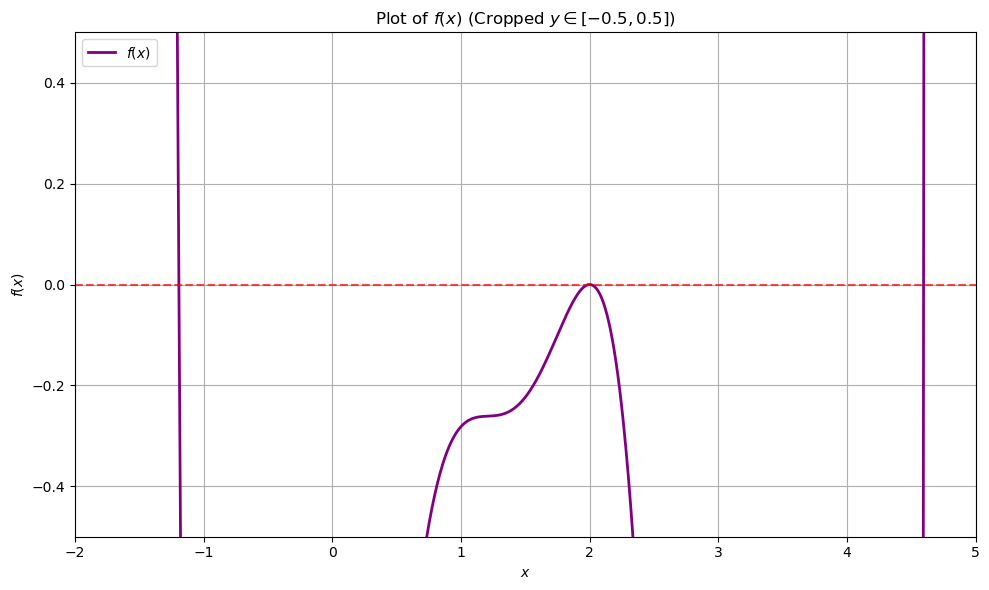

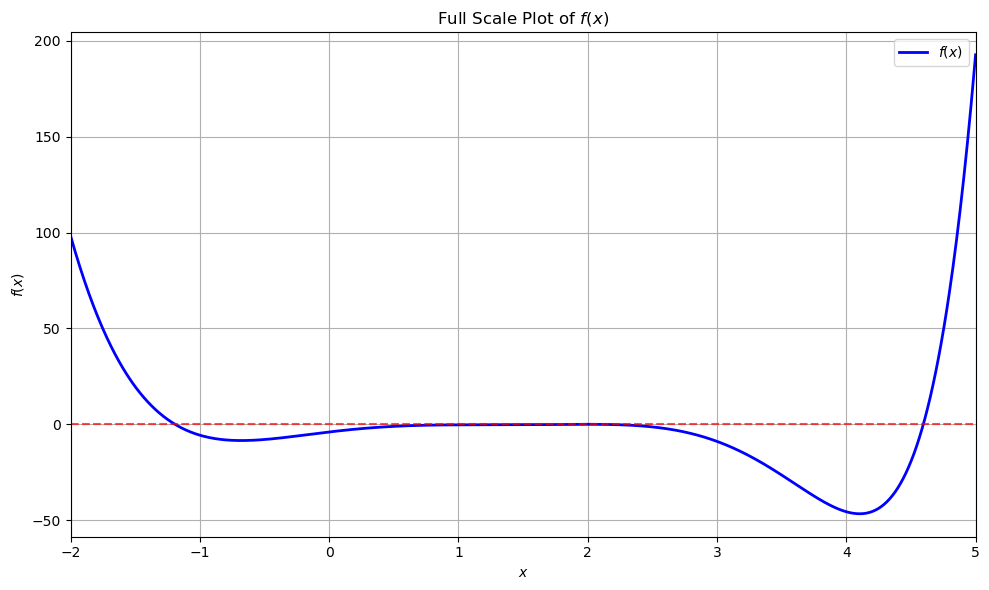

Root 1:
Fixed-Point (g1, xold = -1.5)    : x = -1.1926857629960477
Bisection   (x0 = -2, x1 = 0)    : x = -1.1926857605576515
Secant      (x0 = -2, x1 = -1.5) : x = -1.1926857650225988
Newton      (x0 = -1.5)          : x = -1.1926857650226048

Root 2:
Fixed-Point (g2, xold = 1.8)         : x = 1.9999999476177657
Bisection   (f, x0 = 1.5, x1 = 2.5)  : x = None
Secant      (x0 = 1.9, x1 = 2.1)     : x = 2.0000000393171709
Newton      (x0 = 1.8)               : x = 1.9999685443558120

Root 3:
Fixed-Point (g3, xold = 4.5)     : x = 4.5958635547546649
Bisection   (x0 = 4.0, x1 = 5.0) : x = 4.5958635509014130
Secant      (x0 = 4.0, x1 = 5.0) : x = 4.5958635649223725
Newton      (x0 = 4.5)           : x = 4.5958635649237367



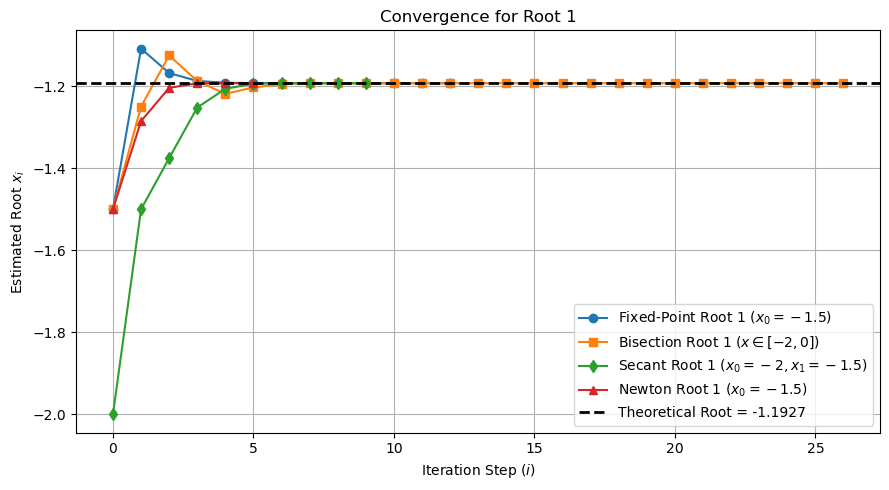

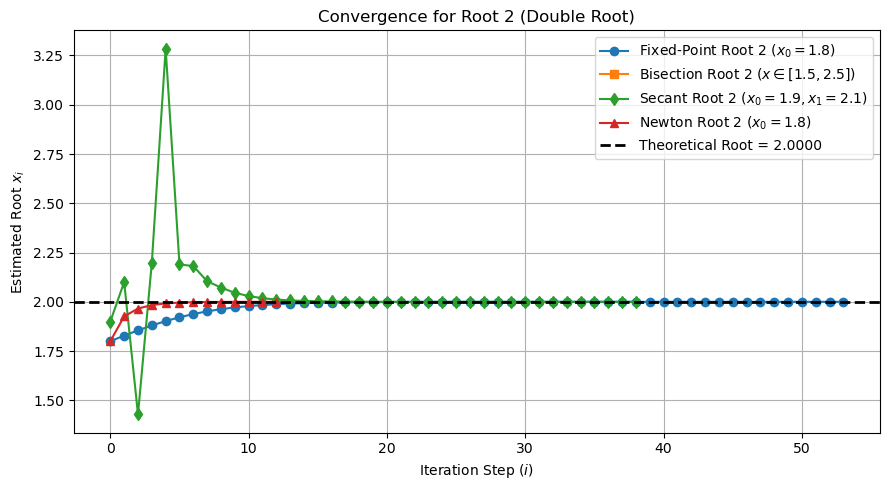

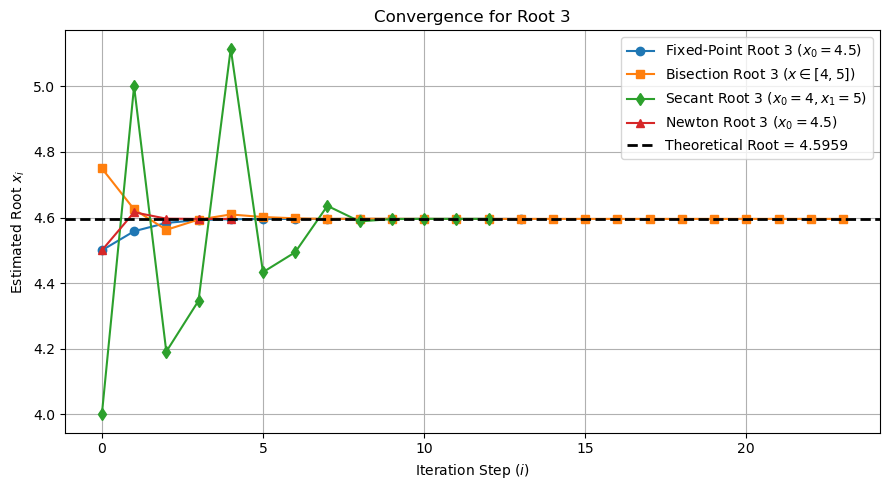

In [28]:
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
#first derivative for newtons method
def df(x):
    return -5*x**4 + 16*x**3 - 12*x**2 - 4*x + 8 + (x**2 - 2*x)*np.exp(x)
    
#fixed-point method
def fixedpoint(f, xold, kmax=200, tol=1.e-8):
    history = [xold] # tracks iteration starting at x0
    for k in range(1, kmax):
        xnew = f(xold) # iterate function g(x)

        xdiff = xnew - xold
        history.append(xnew) # records current estimated iteration

        # stop when relative change between steps falls below tolerance
        if abs(xdiff/xnew) < tol:
            break

        xold = xnew
    else:
        xnew = None

    return xnew, history
    
# bisection method
def bisection(f, x0, x1, kmax=200, tol=1.e-8):
    f0, f1 = f(x0), f(x1)
    if f0*f1 > 0:
        return None, []
    history = []
    for k in range(1, kmax):
        x2 = (x0+x1)/2
        f2 = f(x2)

        # exact root
        if f2 == 0:
            history.append(x2)
            return x2, history
        # shrink interval
        if f0*f2 < 0:
            x1, f1 = x2, f2
        else:
            x0, f0 = x2, f2

        x2new = (x0+x1)/2
        history.append(x2new)
        xdiff = abs(x2new-x2)
        
        if abs(xdiff/x2new) < tol:
            break
    else:
        x2new = None

    return x2new, history

#secant method
def secant(f, x0, x1, kmax=200, tol=1.e-8):
    f0 = f(x0)
    history = [x0, x1]
    for k in range(1, kmax):
        f1 = f(x1)
        ratio = (x1 - x0)/(f1 - f0)
        x2 = x1 - f1*ratio

        xdiff = abs(x2-x1)
        x0, x1 = x1, x2
        f0 = f1
        #rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16}"
        #print(rowf.format(k, x2, xdiff, abs(f(x2))))
        history.append(x2)
        if abs(xdiff/x2) < tol:
            break

    else:
        x2 = None 

    return x2, history

#newtons method
def newton(f, df, x0, kmax=200, tol=1.e-8):
    xold = x0
    history = [xold]
    for k in range(kmax):
        fx = f(xold)

        # stops early if the value is close to zero
        if abs(fx) < tol:
            return xold, history
        dfx = df(xold)

        # prevents division by zero
        if abs(dfx) < 1e-14:
            return None, history

        xnew = xold - fx / dfx
        history.append(xnew)
        xold = xnew
    return None, history
    
x_values = np.linspace(-2, 5, 1000)
y_values = f(x_values)

#plotting f(x) cropped
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, color='purple', linewidth=2, label=r'$f(x)$')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.ylim(-0.5, 0.5)
plt.xlim(-2, 5)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Plot of $f(x)$ (Cropped $y \in [-0.5, 0.5]$)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("fig1.png")
plt.show()

#plotting f(x) full scale
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, color='blue', linewidth=2, label='$f(x)$')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.xlim(-2, 5)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Full Scale Plot of $f(x)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("fig2.png")
plt.show()

# reformulate f(x) = 0 into fixed point iteration forms g(x)
g1 = lambda x: x + 0.02 * f(x)
g2 = lambda x: x + 0.05 * df(x)
g3 = lambda x: x - 0.003 * f(x)

#Root 1
root1_fp, hist1_fp = fixedpoint(g1, xold=-1.5)
root1_bi, hist1_bi = bisection(f, x0=-2.0, x1=0.0)
root1_sc, hist1_sc = secant(f, x0=-2.0, x1=-1.5)
root1_nt, hist1_nt = newton(f, df, x0=-1.5)

print("Root 1:")
print(f"Fixed-Point (g1, xold = -1.5)    : x = {root1_fp:.16f}")
print(f"Bisection   (x0 = -2, x1 = 0)    : x = {root1_bi:.16f}")
print(f"Secant      (x0 = -2, x1 = -1.5) : x = {root1_sc:.16f}")
print(f"Newton      (x0 = -1.5)          : x = {root1_nt:.16f}\n")

#Root 2
root2_fp, hist2_fp = fixedpoint(g2, xold=1.8)
root2_bi, hist2_bi = bisection(f, x0=1.5, x1=2.5)
root2_sc, hist2_sc = secant(f, x0=1.9, x1=2.1)
root2_nt, hist2_nt = newton(f, df, x0=1.8)

print("Root 2:")
print(f"Fixed-Point (g2, xold = 1.8)         : x = {root2_fp:.16f}")
print(f"Bisection   (f, x0 = 1.5, x1 = 2.5)  : x = {root2_bi}")
print(f"Secant      (x0 = 1.9, x1 = 2.1)     : x = {root2_sc:.16f}")
print(f"Newton      (x0 = 1.8)               : x = {root2_nt:.16f}\n")

#Root 3
root3_fp, hist3_fp = fixedpoint(g3, xold=4.5)
root3_bi, hist3_bi = bisection(f, x0=4.0, x1=5.0)
root3_sc, hist3_sc = secant(f, x0=4.0, x1=5.0)
root3_nt, hist3_nt = newton(f, df, x0=4.5)

print("Root 3:")
print(f"Fixed-Point (g3, xold = 4.5)     : x = {root3_fp:.16f}")
print(f"Bisection   (x0 = 4.0, x1 = 5.0) : x = {root3_bi:.16f}")
print(f"Secant      (x0 = 4.0, x1 = 5.0) : x = {root3_sc:.16f}")
print(f"Newton      (x0 = 4.5)           : x = {root3_nt:.16f}\n")

# roots solved analytically
r1 = -1.1926857650
r2 = 2.0
r3 = 4.5958635649

# 1. Plot for Root 1
plt.figure(figsize=(9, 5))
plt.plot(hist1_fp, marker='o', label="Fixed-Point Root 1 ($x_0=-1.5$)")
plt.plot(hist1_bi, marker='s', label="Bisection Root 1 ($x \in [-2, 0]$)")
plt.plot(hist1_sc, marker='d', label="Secant Root 1 ($x_0=-2, x_1=-1.5$)")
plt.plot(hist1_nt, marker='^', label="Newton Root 1 ($x_0=-1.5$)")
plt.axhline(r1, color='black', linestyle='--', linewidth=2.0, label=f"Theoretical Root = {r1:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimated Root $x_i$')
plt.title('Convergence for Root 1')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("fig3.png")
plt.show()

# 2. Plot for Root 2
plt.figure(figsize=(9, 5))
plt.plot(hist2_fp, marker='o', label="Fixed-Point Root 2 ($x_0=1.8$)")
plt.plot(hist2_bi, marker='s', label="Bisection Root 2 ($x \in [1.5, 2.5]$)")
plt.plot(hist2_sc, marker='d', label="Secant Root 2 ($x_0=1.9, x_1=2.1$)")
plt.plot(hist2_nt, marker='^', label="Newton Root 2 ($x_0=1.8$)")
plt.axhline(r2, color='black', linestyle='--', linewidth=2.0, label=f"Theoretical Root = {r2:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimated Root $x_i$')
plt.title('Convergence for Root 2 (Double Root)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("fig4.png")
plt.show()

# 3. Plot for Root 3
plt.figure(figsize=(9, 5))
plt.plot(hist3_fp, marker='o', label="Fixed-Point Root 3 ($x_0=4.5$)")
plt.plot(hist3_bi, marker='s', label="Bisection Root 3 ($x \in [4, 5]$)")
plt.plot(hist3_sc, marker='d', label="Secant Root 3 ($x_0=4, x_1=5$)")
plt.plot(hist3_nt, marker='^', label="Newton Root 3 ($x_0=4.5$)")
plt.axhline(r3, color='black', linestyle='--', linewidth=2.0, label=f"Theoretical Root = {r3:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimated Root $x_i$')
plt.title('Convergence for Root 3')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("fig5.png")
plt.show()

0.0


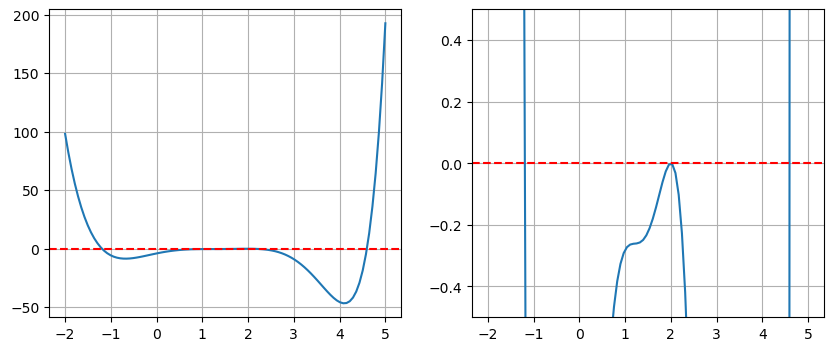

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

This code finds the three roots of $f(x)$ (about −1.19, 2 and 4.60) with four methods: fixed-point, bisection, Newton, and secant. Each method returns its full list of iterates, so the convergence plots come straight from the results, and each has an iteration cap and tolerance. Bisection checks for a sign change first, which is why it refuses the double root at $x$ = 2. $f(x)$ is evaluated at 1000 points from $x$ = −2 to 5, and each convergence plot draws every method's iterates against the iteration number, with a dashed line at the true root.